SpecArray and SpecDataset are extensions of xarray's DataArray and Dataset

http://xarray.pydata.org/en/stable/getting-started-guide/quick-overview.html



constructing a DataArray
--------------------------

In [1]:
import numpy as np
import xarray as xr

freqs = np.linspace(0.02, 1, num=20)
dirs = np.arange(0,300, step=60, dtype=float)

nFreqs = len(freqs)
nDirections = len(dirs)

# make a random spectrum
spectral_density = np.random.rand(nFreqs, nDirections) / 50

One of the key features of xarray is the possibility to label the dimensions of your data.
In this case the spectral-data has two dimensions: frequency and heading.

We can pass these names when constructing a data-array using the "dims" argument. The order of the names in the dims
argument needs to match the order of dimensions of the data.

In this case the data is spectral_density[frequency, direction] so the dims
arugument will be ('freq','dir')

In [2]:
da = xr.DataArray(spectral_density,
                  dims = ("freq", "dirs"))

This gives us a "DataArray" with two dimensions: frequency and direction.

Next step is to provide the actual values associated with the dimensions. In xarray terminology this is called
"defining coordinates for a dimension".

This is done by supplying a dictionary with
- key: name of the dimension
- values: array with values of the grid in that dimension

Obviously the length of the "values" should match the size of the data in that dimension.


In [3]:
coordinates_for_dimensions = dict()
coordinates_for_dimensions['freq'] = freqs
coordinates_for_dimensions['dirs'] = dirs

da = xr.DataArray(spectral_density,
                  dims = ("freq", "dirs"),
                  coords = coordinates_for_dimensions)


# or, shorter

da = xr.DataArray(spectral_density,
                  dims = ("freq", "dirs"),
                  coords ={'freq':freqs,
                           'dirs':dirs})


In [4]:
# print
print(da)

<xarray.DataArray (freq: 20, dirs: 5)>
array([[0.00433973, 0.00757323, 0.01021138, 0.00923332, 0.00514492],
       [0.01202191, 0.01033122, 0.01247979, 0.00789039, 0.01230879],
       [0.01776997, 0.01786439, 0.01806511, 0.0070833 , 0.01396319],
       [0.00950455, 0.00611996, 0.00069965, 0.01518823, 0.00717681],
       [0.007917  , 0.01836576, 0.01501559, 0.00981036, 0.00441034],
       [0.01478443, 0.00035598, 0.00881253, 0.01089905, 0.01862504],
       [0.00641674, 0.00385606, 0.00850126, 0.01270803, 0.0139206 ],
       [0.00586201, 0.01833825, 0.00813124, 0.0081344 , 0.00805184],
       [0.01076703, 0.00024886, 0.00135632, 0.01221359, 0.01818999],
       [0.01875675, 0.00369632, 0.00602219, 0.01440587, 0.0184116 ],
       [0.0067097 , 0.01916237, 0.00662333, 0.00522556, 0.01630688],
       [0.01764458, 0.01279276, 0.01611865, 0.00658029, 0.01704513],
       [0.0016418 , 0.01906633, 0.00244051, 0.01782685, 0.01332737],
       [0.00784274, 0.00788034, 0.01007314, 0.01878787, 0.002859

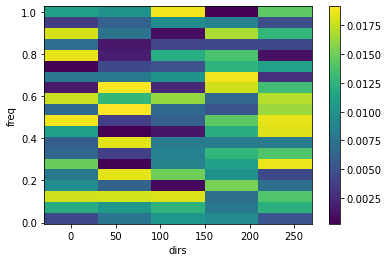

In [5]:
# plot
da.plot.pcolormesh()

DataSet
-------

A DataArray contains a single data-variable. In this case we named this variable 'efth', but that naming is optional.

A DataSet allows for multiple data-variables. This is useful when more data is available on the same grid. For example:

waves: available are time, dir, freq
wind-speed: available in time-dimension
wind-direction: available in time-dimension

A data-array can be converted into a data-set using the to_dataset() method:

In [14]:
ds = da.to_dataset(name = 'spectral_density')

ds

<xarray.Dataset>
Dimensions:            (dir: 5, dirs: 5, freq: 20)
Coordinates:
  * freq               (freq) float64 0.02 0.07158 0.1232 ... 0.8968 0.9484 1.0
  * dirs               (dirs) float64 0.0 60.0 120.0 180.0 240.0
Dimensions without coordinates: dir
Data variables:
    spectral_density   (freq, dirs) float64 0.00434 0.007573 ... 0.01437
    distance_to_shore  (dir) float64 0.3998 0.3747 0.386 0.4872 0.8387

Adding new "data-variables" can be done as follows:

In [15]:
distance_to_shore = np.random.rand(nDirections)
ds['distance_to_shore'] = ('dir', distance_to_shore)

ds


<xarray.Dataset>
Dimensions:            (dir: 5, dirs: 5, freq: 20)
Coordinates:
  * freq               (freq) float64 0.02 0.07158 0.1232 ... 0.8968 0.9484 1.0
  * dirs               (dirs) float64 0.0 60.0 120.0 180.0 240.0
Dimensions without coordinates: dir
Data variables:
    spectral_density   (freq, dirs) float64 0.00434 0.007573 ... 0.01437
    distance_to_shore  (dir) float64 0.9384 0.2849 0.06326 0.02712 0.5656

SpecArray and SpecDataset
==========================

A SpecArray is a DataArray containing data in pre-defined places and with methods that can do something with this data.
A SpecDataset is the Dataset equivalent. So just a SpecArray with some additional data-variables.

Creating a SpecArray
---------------------

SpecArrays extend DataArray.

In order for SpecArray to know what the data means, we need to stick to agreed names and units.

These are the rules:

- the spectral-density has name 'efth'
- if a time-dimension is present, it shall have the name 'time'
- direction name is 'dir' [degrees]
- frequency name is 'freq' [hz]


Setup a DataArray and Dataset with the proper namings:

In [19]:
da = xr.DataArray(spectral_density,
                  name = 'efth',
                  dims = ("freq", "dir"),
                  coords ={'freq':freqs,
                           'dir':dirs})

ds = da.to_dataset()

Notes:
- instead of hard-coding these names it is recommended to use the constants as defined in from wavespectra.core.attributes import attrs instead:


In [20]:
from wavespectra.core.attributes import attrs
attrs

{'SPECNAME': 'efth',
 'TIMENAME': 'time',
 'SITENAME': 'site',
 'LATNAME': 'lat',
 'LONNAME': 'lon',
 'FREQNAME': 'freq',
 'DIRNAME': 'dir',
 'PARTNAME': 'part',
 'CYCLENAME': 'cycle',
 'WSPDNAME': 'wspd',
 'WDIRNAME': 'wdir',
 'DEPNAME': 'dpt',
 'ATTRS': {'efth': {'standard_name': 'sea_surface_wave_directional_variance_spectral_density',
   'units': 'm2 s degree-1'},
  'time': {'standard_name': 'time'},
  'lat': {'standard_name': 'latitude', 'units': 'degrees_north'},
  'lon': {'standard_name': 'longitude', 'units': 'degrees_east'},
  'site': {'standard_name': 'site', 'units': ''},
  'freq': {'standard_name': 'sea_surface_wave_frequency', 'units': 'Hz'},
  'dir': {'standard_name': 'sea_surface_wave_from_direction',
   'units': 'degree'},
  'part': {'standard_name': 'spectral_partition_number', 'units': ''},
  'cycle': {'standard_name': 'forecast_reference_time'},
  'wspd': {'standard_name': 'wind_speed_at_10m_above_ground_level',
   'units': 'm s-1'},
  'wdir': {'standard_name': 'wind

### Creating a SpecArray from a DataArray

If the xarray has the proper namings we can create a SpecArray from it.

This allows using all the awesome functionality from SpecArray:


In [21]:
from wavespectra import SpecArray
sa = SpecArray(da)

sa.hs()

<xarray.DataArray 'hs' ()>
array(7.8554321)
Attributes:
    standard_name:  sea_surface_wave_significant_height
    units:          m

In [22]:
type(sa)

wavespectra.specarray.SpecArray

### Getting a SpecDataset from a DataSet

First import SpecDataset, this adds the .spec property to DataSet.


In [24]:
from wavespectra import SpecDataset

spec_arr = ds.spec
spec_arr.hs()

print(type(spec_arr))

<class 'wavespectra.specdataset.SpecDataset'>


<SpecDataset>
Dimensions:  (dir: 5, freq: 20)
Coordinates:
  * freq     (freq) float64 0.02 0.07158 0.1232 0.1747 ... 0.8968 0.9484 1.0
  * dir      (dir) float64 0.0 60.0 120.0 180.0 240.0
Data variables:
    efth     (freq, dir) float64 0.00434 0.007573 0.01021 ... 0.0003142 0.01437

# Data-manipulation

For example SpecArray knows that direction 360 is the same as direction 0, so interpolating between directions works:

No - it doesn't :-/, not yet implemented

In [ ]:
sa.interp(dir=350)

In [ ]:
da.interp(dir=350)

In [ ]:
da

In [ ]:
# ? How can this still work.... ?

da_faulty = xr.DataArray(spectral_density,
                  dims = ("foo", "bar"))

ds_faulty = da_faulty.to_dataset(name='test')

ds_faulty.spec.hs()